### 🤖 Multi-Agent Network RAG System with LangGraph

Project Overview
A beginner-friendly Retrieval-Augmented Generation (RAG) system that use a multi-agent architecture to intelligently answer questions from the documents. Built with LangGraph v0.3 for workflow orchestration and Groq for language understanding.

What it Does
Transforms the documents (PDFs, Text files) into a searchable knowledge base that can answer questions intelligently using AI. Simply upload documents and ask question in natural language - the system finds relevant information and generates comprehensive answers.

Key Features:
- `📚 Multi-Format Support`: Handles PDF and Text documents
- `🤖 3-Agent Architecture`: Specialized agents for document processing, retrieval and answer generation
- `🔎 Smart Search`: Vector-based semantic search finds relevant information
- `📝 Natural Language Q&A`: Ask questions in plain English

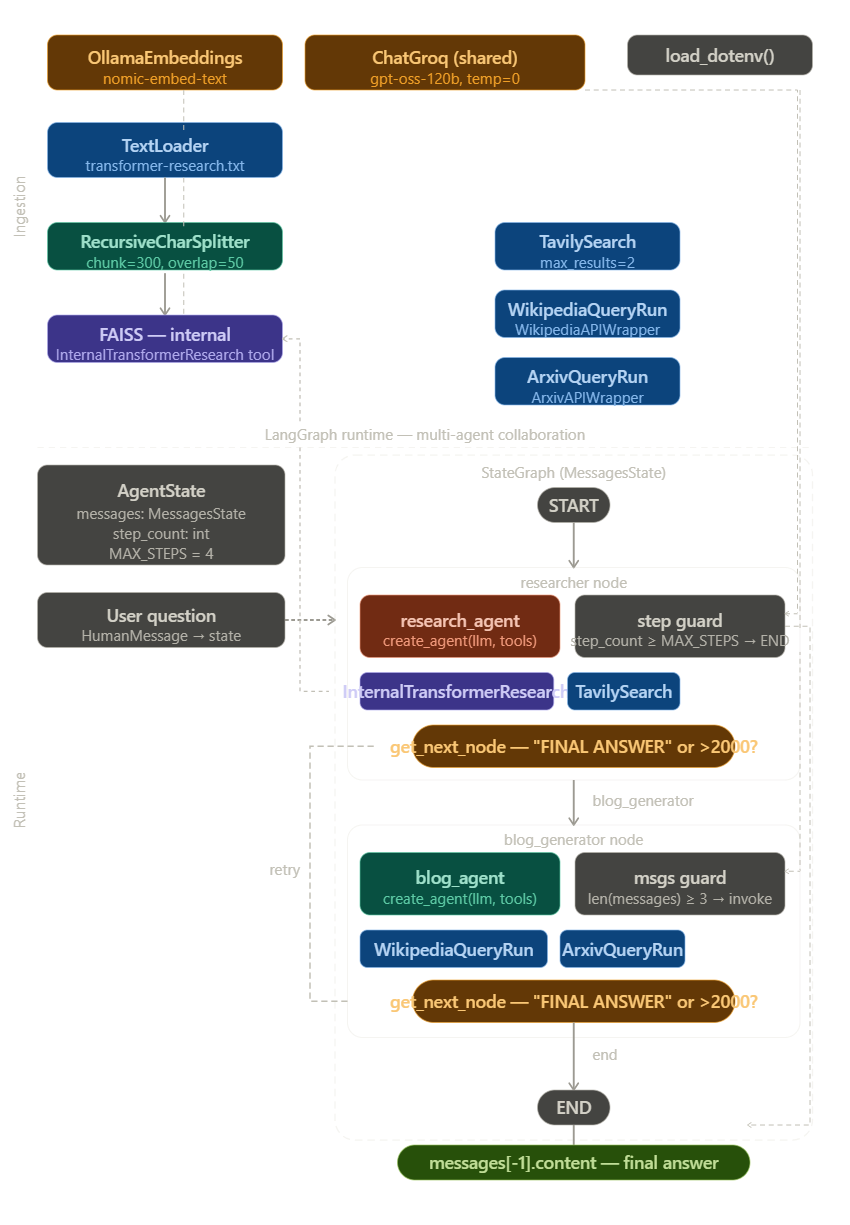

In [47]:
# ------------------------------------------------------------
# 1. LLM and Embeddings 
# ------------------------------------------------------------

from langchain_groq import ChatGroq
from langchain_ollama.embeddings import OllamaEmbeddings
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')
os.environ['TAVILY_API_KEY'] = os.getenv('tavily_api_key')

llm = ChatGroq(model='openai/gpt-oss-120b', max_tokens=1000, temperature=0)
embedding = OllamaEmbeddings(model='nomic-embed-text')

### 🛒 1. Researcher Agent

In [48]:
# ------------------------------------------------------------
# 2. Retriever - Text File and Tools
# ------------------------------------------------------------

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_classic.agents import Tool

# Text File
def make_retriever_tool_from_text(file, name, desc):
    docs = TextLoader(file_path=file, encoding='utf-8').load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50).split_documents(docs)
    vector_db = FAISS.from_documents(chunks, embedding)
    retriever = vector_db.as_retriever()
    
    def tool_func(query: str) -> str:
        print(f'🔨 Using Tool: {name}')
        results = retriever.invoke(query)
        return '\n\n'.join(doc.page_content[:300] for doc in results[:3])
    return Tool(name=name, description=desc, func=tool_func)

internal_tool_text = make_retriever_tool_from_text(
    'data/transformer-research.txt',
    'InternalTransformerResearch',
    'Searching transformer research notes for experimental results'
)

from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)

In [49]:
# ------------------------------------------------------------
# 3. Node - Decision
# ------------------------------------------------------------

from langchain_core.messages import BaseMessage
from langgraph.graph import END

def get_next_node(last_message: BaseMessage, goto: str):
    content = last_message.content.lower()
    
    if 'final answer' in content:
        return END
    
    # 🔥 safety stop
    if len(content) > 2000:  
        return END
        
    return goto

In [50]:
# ------------------------------------------------------------
# 4. Prompt
# ------------------------------------------------------------

def make_system_prompt(suffix: str) -> str:
    return f"""
        You are a helpful AI assistant collaborating with other assistants.

        You MUST follow these rules:
        1. Do your task using available tools.
        2. If you have enough information to answer the user question → respond with FINAL ANSWER.
        3. DO NOT loop forever. If progress is sufficient, finalize.

        {suffix}
    """

In [51]:
from typing import TypedDict

class AgentState(MessagesState):
    step_count: int

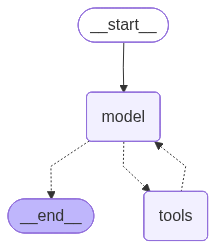

In [52]:
# ------------------------------------------------------------
# 5. Create Agent - Researcher
# ------------------------------------------------------------

from langchain.agents import create_agent

research_agent = create_agent(
    model=llm,
    tools=[internal_tool_text, tavily_tool],
    system_prompt=make_system_prompt('You can only do research. Use the tools that you are bind and you can use both of them. You are working with a content writer colleague.')
)

research_agent

In [53]:
# ------------------------------------------------------------
# 6. Research Node
# ------------------------------------------------------------

from typing import Literal
from langgraph.graph import MessagesState, END
from langgraph.types import Command
from langchain_core.messages import HumanMessage

MAX_STEPS = 4

def research_node(state: AgentState) -> Command[Literal['researcher', END]]:
    step = state.get("step_count", 0)
    
    if step >= MAX_STEPS:
        return Command(goto=END)
    
    result = research_agent.invoke(state)
    
    goto = get_next_node(last_message=result['messages'][-1], goto='blog_generator')
    
    # Wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result['messages'][-1] = HumanMessage(
        content=result['messages'][-1].content,
        name='researcher'
    )
    return Command(
        update={
            # Share internal message history of research agent with other agents
            'messages': result['messages'][-6:],
            'step_count': step + 1
        }, goto=goto
    )

### 📝 2. Blogger Agent

In [54]:
# ------------------------------------------------------------
# 1. Blogger - Arxiv and Wikipedia
# ------------------------------------------------------------

from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun

# Wikipedia Tool
wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

# ArXiv Tool
arxiv = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

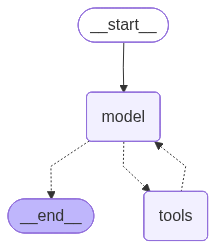

In [55]:
# ------------------------------------------------------------
# 2. Create Agent - Blogger
# ------------------------------------------------------------

from langchain.agents import create_agent

blog_agent = create_agent(
    model=llm,
    tools=[wiki, arxiv],
    system_prompt=make_system_prompt('You can only do research. Use the tools that you are bind and you can use both of them. You are working with a content writer colleague.')
)
blog_agent

In [56]:
# ------------------------------------------------------------
# 3. Blogger Node
# ------------------------------------------------------------

from langchain_core.messages import HumanMessage

MAX_STEPS = 4

def blog_node(state: AgentState) -> Command[Literal['researcher', END]]:
    last_msgs = state["messages"]
    
    # If enough info → force final answer
    if len(last_msgs) >= 3:        
        result = blog_agent.invoke(state)
        goto = get_next_node(last_message=result['messages'][-1], goto='researcher')
    
        # Wrap in a human message, as not all providers allow
        # AI message at the last position of the input messages list
        result['messages'][-1] = HumanMessage(
            content=result['messages'][-1].content, name='blog_generator'
        )
        return Command(
            update={
                # Share internal message history of chart agent with other agent
                'messages': result['messages'][-6:]
            },
            goto=goto
        )

### 📊 LangGraph Agent State

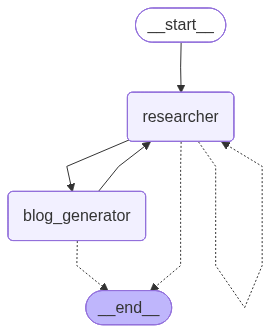

In [57]:
from langgraph.graph import StateGraph, START
from IPython.display import Image, display

workflow = StateGraph(MessagesState)

workflow.add_node('researcher', research_node)
workflow.add_node('blog_generator', blog_node)

workflow.add_edge(START, 'researcher')
workflow.add_edge('researcher', 'blog_generator')
workflow.add_edge('blog_generator', 'researcher')

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
query = 'What is about transformer variants?'

state = {'messages': [HumanMessage(content=query)]}
result = graph.invoke(state)

print('\n✅ Final Answer:\n', result['messages'][-1].content)